In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, IsolationForest



In [4]:
# Load processed credit card dataset
df = pd.read_csv("/Users/thakur/Documents/Documents-Alok-MacBook-Air/LearnPython/SAFE-AI-Fraud-Investigation/data/processed/creditcard_processed.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   V1                 284807 non-null  float64
 1   V2                 284807 non-null  float64
 2   V3                 284807 non-null  float64
 3   V4                 284807 non-null  float64
 4   V5                 284807 non-null  float64
 5   V6                 284807 non-null  float64
 6   V7                 284807 non-null  float64
 7   V8                 284807 non-null  float64
 8   V9                 284807 non-null  float64
 9   V10                284807 non-null  float64
 10  V11                284807 non-null  float64
 11  V12                284807 non-null  float64
 12  V13                284807 non-null  float64
 13  V14                284807 non-null  float64
 14  V15                284807 non-null  float64
 15  V16                284807 non-null  float64
 16  V17          

## Phase-3
### Building ML-Pipeline
ML pipeline steps:
1. Prepare Data
    1.	Split data 
    2.	Separate numeric & categorical 
    3.	Encode categorical 
    4.	Scale numeric 
2.	Train model 

#### Preparing data for ML Pipeline

In [5]:
# Define X and Y
# Class = 0 -> Normal Transaction
# Class = 1 -> Fraudulent Transaction

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=912, stratify=y)

categorical_cols = ["Amount_Bucket"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

In [6]:
encoder = OneHotEncoder(drop=["Very Low"], handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [7]:
encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

X_train_num = X_train[numerical_cols]
X_test_num = X_test[numerical_cols]

X_train_final = pd.concat([X_train_num, X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_df], axis=1)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)


#### Training Logistic Regression Model

In [9]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [26]:
y_prob = model.predict_proba(X_test_scaled) [:,1]

y_pred = (y_prob > 0.8).astype(int)

In [28]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

[[56426   438]
 [   12    86]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.88      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.93      0.64     56962
weighted avg       1.00      0.99      0.99     56962

ROC AUC Score: 0.973979358555465


Did some threshold adjustment here from 0.5 to 0.7 and noticed following:  
1. The default threshold of 0.5 resulted in a high number of false positives  
2. The threshold was increased to 0.7 to reduce incorrect fraud predictions  
3. This reduced false positives significantly while maintaining high recall  
4. Precision improved from 0.06 to 0.11  
5. Recall remained high at 0.89, indicating most fraud cases are still detected  

#### Training Random Forest Model

In [12]:
# Defining model parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=912
)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
y_pred_rf = (y_prob_rf > 0.9).astype(int)

In [25]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

[[56864     0]
 [   52    46]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.47      0.64        98

    accuracy                           1.00     56962
   macro avg       1.00      0.73      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9423766552203323


#### Model Comparison
When using a higher classification threshold (0.9), Logistic Regression maintained high recall (0.85), successfully identifying most fraud cases, though with moderate false positives. In contrast, Random Forest achieved perfect precision with zero false positives but suffered a significant drop in recall (0.47), missing more than half of the fraud cases.

This highlights that Logistic Regression is more suitable for fraud detection where minimizing missed fraud is critical, while Random Forest is more conservative and better suited for scenarios requiring extremely low false alarms.  

I also experimented with multiple thresholds and selected 0.8 as it reduced false positives significantly while maintaining high recall, which is critical in fraud detection.

`Final Recommendation`  
Model: `Logistic Regression`  
Threshold: `0.8`  
Reason: `Best balance of recall vs false positives`  

### Phase-4
#### Behavioral Anomaly Detection

In [32]:
# Behvioral Anomaly Detection using Isolation Forest Model
# Defining attributes for Isolation Model

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=912
)

iso_model.fit(X_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.002
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",912
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


#### Generate anomaly outputs on test data set

In [33]:
# decision_function: higher = more normal, lower = more anomalous
anomaly_score = iso_model.decision_function(X_test_scaled)

# predict returns 1 for normal and -1 for anomaly
anomaly_pred = iso_model.predict(X_test_scaled)

# convert to clean binary flag - anomaly = 1; normal = 0
anomaly_flag = np.where(anomaly_pred == -1,1,0)

#### Generate results dataframe
To compare anomaly signals against true fraud signals

In [37]:
anomaly_results = pd.DataFrame({
    "actual_class": y_test.values,
    "anomaly_score": anomaly_score,
    "anomaly_flag": anomaly_flag
}, index=y_test.index)

#anomaly_results.head()

print(confusion_matrix(anomaly_results["actual_class"], anomaly_results["anomaly_flag"]))
print(classification_report(anomaly_results["actual_class"], anomaly_results["anomaly_flag"]))

[[56777    87]
 [   77    21]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.19      0.21      0.20        98

    accuracy                           1.00     56962
   macro avg       0.60      0.61      0.60     56962
weighted avg       1.00      1.00      1.00     56962



#### Compare average anomaly score by class

In [38]:
anomaly_results.groupby("actual_class")["anomaly_score"].mean()

actual_class
0    0.240506
1    0.075982
Name: anomaly_score, dtype: float64

#### Visualize anomaly score distribution by class

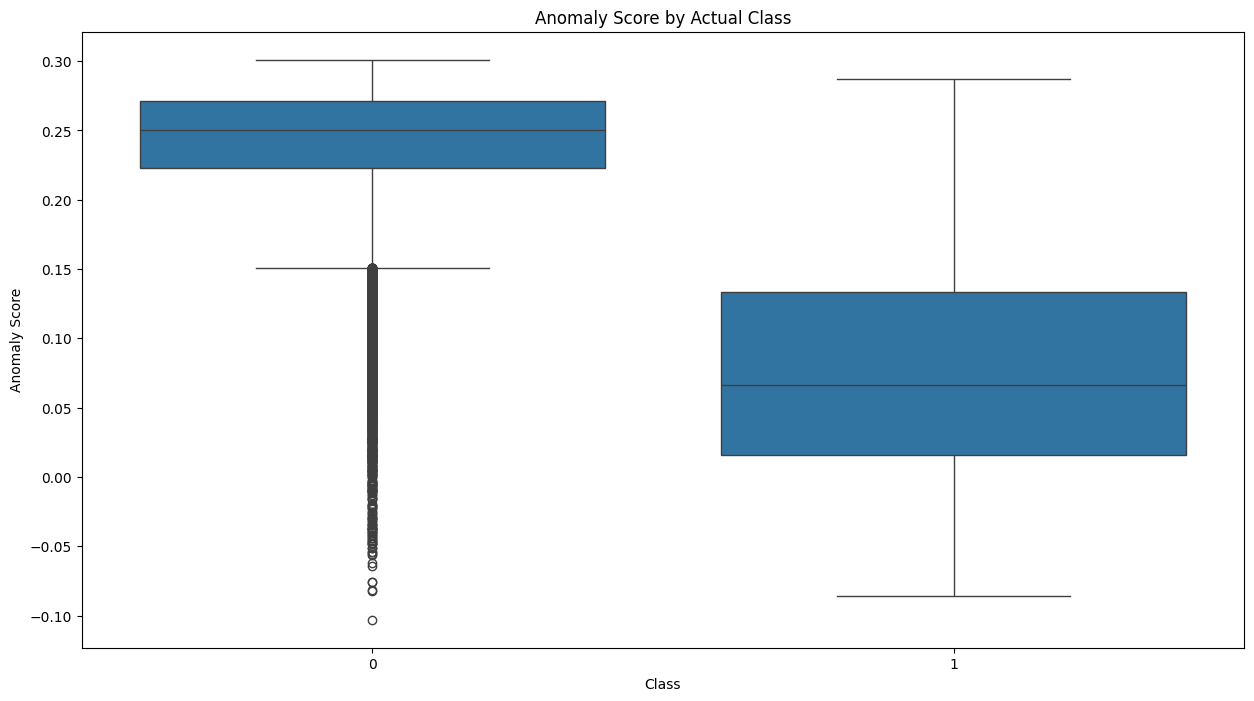

In [39]:
plt.figure(figsize=(15,8))
sns.boxplot(x="actual_class", y="anomaly_score", data=anomaly_results)
plt.title("Anomaly Score by Actual Class")
plt.xlabel("Class")
plt.ylabel("Anomaly Score")
plt.show()

In [40]:
anomaly_flag_rate = anomaly_results.groupby("actual_class")["anomaly_flag"].mean()*100
print(anomaly_flag_rate)

actual_class
0     0.152997
1    21.428571
Name: anomaly_flag, dtype: float64


#### Anomaly Detection Analysis
1. Only 0.15% of normal transactions were flagged as anomalies  
2. In contrast, 21.4% of fraudulent transactions were flagged as anomalies  
3. This shows that fraudulent transactions are significantly more likely to exhibit unusual behavior  
4. Although the anomaly model is not a strong standalone classifier, it provides a valuable supporting signal  

In [41]:
test_results = pd.DataFrame(index=y_test.index)
test_results["actual_class"] = y_test
test_results["fraud_probability"] = y_prob
test_results["fraud_prediction"] = y_pred
test_results["anomaly_score"] = anomaly_score
test_results["anomaly_flag"] = anomaly_flag

In [42]:
test_results.to_csv("/Users/thakur/Documents/Documents-Alok-MacBook-Air/LearnPython/SAFE-AI-Fraud-Investigation/data/processed/test_results_with_anomaly.csv", index=True)

#### Behavioral Anomaly Detection

1. Isolation Forest was used as an unsupervised anomaly detection model.  
2. The model was trained on the training data and then applied to the held-out test set.  
3. It produces an anomaly score and an anomaly flag for each transaction.  
4. This layer is not the main fraud detector. It is a supporting signal that helps identify unusual transaction patterns.  

#### Observations

1. Fraudulent transactions generally showed lower anomaly scores than normal transactions.  
2. The anomaly model identified unusual transaction patterns, but it is not expected to perfectly match the fraud labels.  
3. This is acceptable because anomaly detection is used here as a supporting behavioral signal, not as the only fraud detection mechanism.  

The anomaly score will be used as an additional feature alongside the supervised fraud model to improve overall decision-making.